In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pk

In [36]:
df= pd.read_csv("Customer_Churn_Modelling.csv")

In [37]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [38]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# Using Supervised Learning Model

In [39]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,accuracy_score

In [40]:
df.keys()

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [41]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'],inplace=True)


In [42]:
df.select_dtypes(include=object)

,Geography,Gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female
...,...,...
9995,France,Male
9996,France,Male
9997,France,Female
9998,Germany,Male


# Label Encoding

In [43]:
geo_encode = LabelEncoder()
gender_encode = LabelEncoder()

In [44]:
df['Geography'] = geo_encode.fit_transform(df['Geography'])
df['Gender'] = gender_encode.fit_transform(df['Gender'])

In [45]:
df.keys()

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [46]:
df['EstimatedSalary'].max()

199992.48

In [47]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


# Finding the Outliers

<Axes: ylabel='CreditScore'>

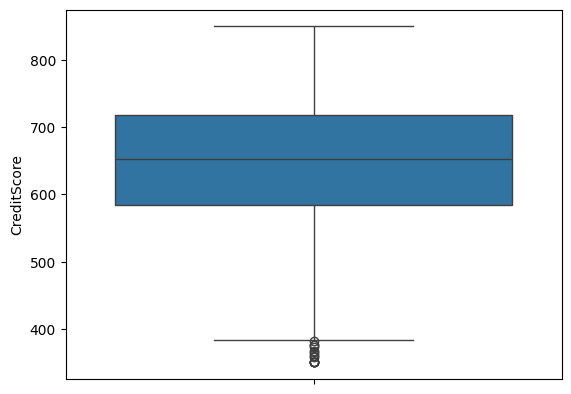

In [48]:
sns.boxplot(df['CreditScore'])

<Axes: ylabel='Age'>

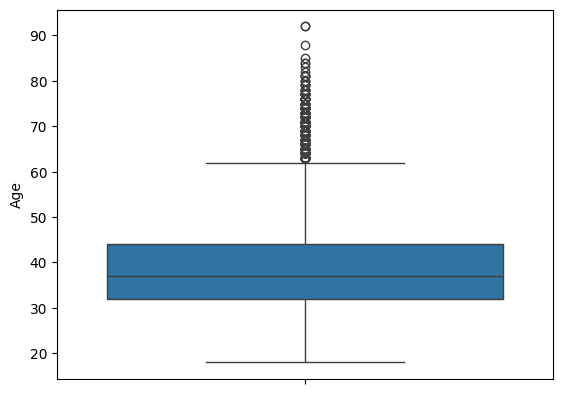

In [49]:
sns.boxplot(df['Age'])

<Axes: ylabel='Balance'>

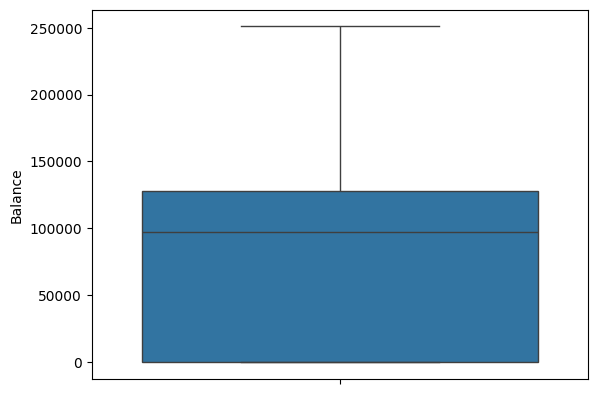

In [50]:
sns.boxplot(df['Balance'])

<Axes: ylabel='EstimatedSalary'>

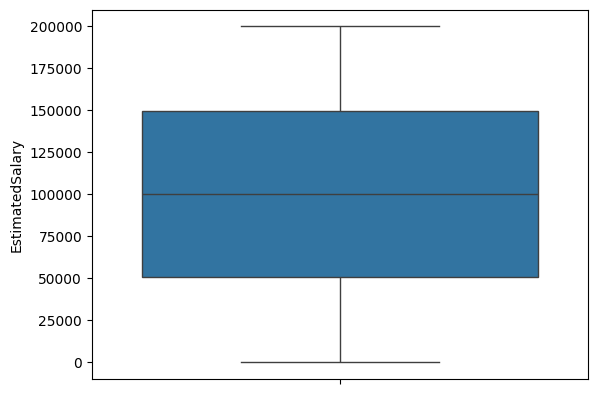

In [ ]:
sns.boxplot(df['EstimatedSalary'])

In [ ]:
q1  = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
iqr = q3 - q1

In [ ]:
df['Age']

0       42
1       41
2       42
3       39
4       43
        ..
9995    39
9996    35
9997    36
9998    42
9999    28
Name: Age, Length: 10000, dtype: int64

In [ ]:
lower_limit = q1-(1.5*iqr)
upper_limit = q3+(1.5*iqr)

In [ ]:
new_df = df.loc[(df['Age'] <= upper_limit) & (df['Age'] >= lower_limit)]

In [ ]:
new_df['Age'].max()

62

<Axes: >

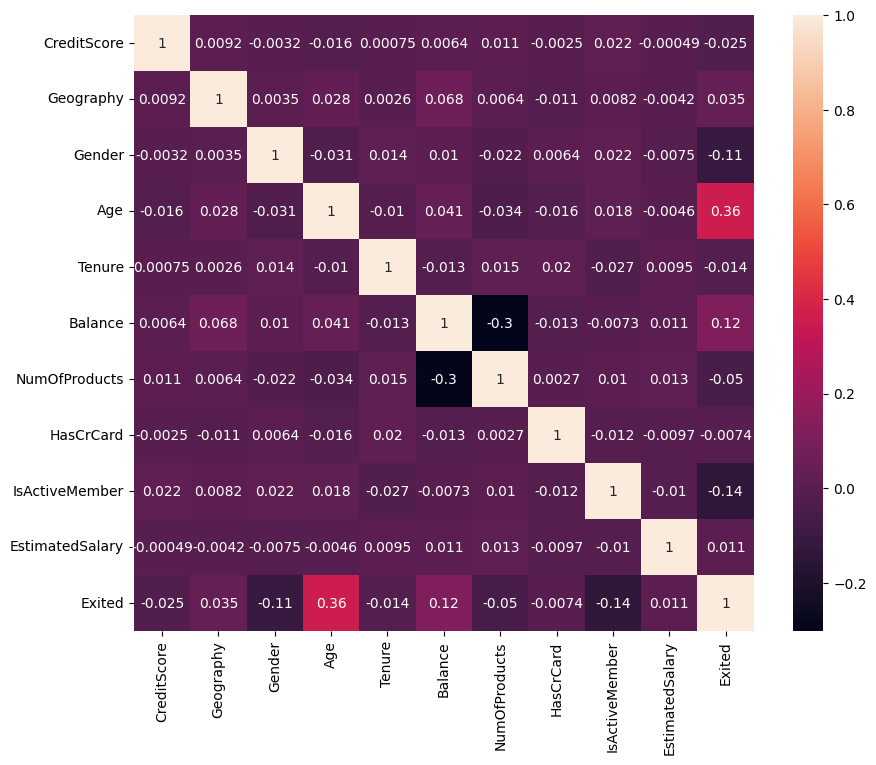

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(new_df.corr(),annot=True)

In [ ]:
new_df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


<Axes: ylabel='Age'>

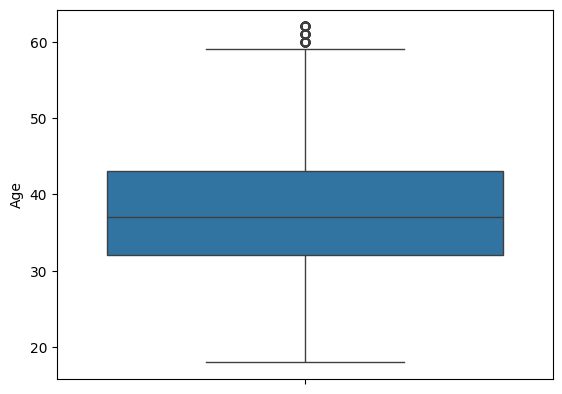

In [ ]:
sns.boxplot(new_df['Age'])

In [ ]:
x = new_df.drop(columns="Exited")
y = new_df[["Exited"]]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=23)

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
model1 = LogisticRegression()

In [ ]:
model1.fit(x_train_scaled,y_train)
y_pred1 = model1.predict(x_test_scaled)
accuracy_score(y_test,y_pred1)

c:\Users\INDIA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8087091757387247

In [ ]:
model2 = XGBClassifier()

In [ ]:
model2.fit(x_train_scaled,y_train)
y_pred2 = model2.predict(x_test_scaled)
accuracy_score(y_test,y_pred2)

0.8341109383100052

# Using ANN (Artificial Neural Networks)

In [ ]:
import tensorflow as tns
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten,Dense,InputLayer,Dropout
from tensorflow.keras.optimizers import Adam

KeyboardInterrupt: 

In [ ]:
model3 = Sequential()

In [ ]:
#HiddenLayer1
model3.add(Dense(64,activation="relu", input_dim=x_train_scaled.shape[1]))
model3.add(Dropout(0.3))

c:\Users\INDIA\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#HiddenLayer2
model3.add(Dense(32,activation="relu"))
model3.add(Dropout(0.3))

In [ ]:
#HiddenLayer3
model3.add(Dense(16,activation="relu"))

In [ ]:
model3.add(Dense(1,activation="sigmoid"))

In [ ]:
model3.compile(optimizer="adam",loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.fit(x_train,y_train,epochs=50,validation_split=0.2,batch_size=32)

Epoch 1/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6724 - loss: 571.4691 - val_accuracy: 0.7959 - val_loss: 2.7543
Epoch 2/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6758 - loss: 63.0804 - val_accuracy: 0.4018 - val_loss: 0.8578
Epoch 3/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6813 - loss: 23.6868 - val_accuracy: 0.7959 - val_loss: 0.6051
Epoch 4/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7000 - loss: 11.3740 - val_accuracy: 0.7959 - val_loss: 0.6879
Epoch 5/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7134 - loss: 5.3445 - val_accuracy: 0.7959 - val_loss: 0.5440
Epoch 6/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7295 - loss: 3.6324 - val_accuracy: 0.7959 - val_loss: 0.5726
Epoch 7/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7580 - loss: 2.2698 - val_accuracy: 0.7959 - val_loss: 0.5799
Epoch 8/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7598 - loss: 2.1103 - val_accurac

In [ ]:
loss,accuracy = (model3.evaluate(x_test_scaled,y_test))

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7854 - loss: 0.5207


In [ ]:
loss

0.5207012891769409

In [ ]:
accuracy

0.785381019115448

In [ ]:
y_pred = model3.predict(x_test_scaled)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
y_pred = (y_pred > 0.5).astype(int)

In [ ]:
accuracy_score(y_test,y_pred)

0.7853810264385692

In [ ]:
pk.dump(geo_encode,open("geo_encode.pkl","wb"))
pk.dump(gender_encode,open("gender_encode.pkl","wb"))
pk.dump(scaler,open("scaler.pkl","wb"))
pk.dump(model1,open("logisticreg.pkl","wb"))
pk.dump(model2,open("xgboost.pkl","wb"))
pk.dump(model3,open("ann.pkl","wb"))